# Ячейка 1: Импорт библиотек и настройка

ПРОСТОЙ АНАЛИЗ ДАННЫХ ОТКАЗОВ ОБОРУДОВАНИЯ
Учебный notebook для поиска взаимосвязей в данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Настройки для красивого отображения
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Библиотеки загружены")

✅ Библиотеки загружены


# Ячейка 2: Загрузка данных

ЗАГРУЗКА ДАННЫХ ИЗ CSV ФАЙЛОВ
У нас есть два файла: train.csv и test.csv
Обычно train.csv используется для обучения, test.csv для проверки

In [2]:
print("📁 ЗАГРУЗКА ДАННЫХ...")
print("-" * 50)

# Загружаем тренировочные данные
train_df = pd.read_csv('train.csv')
print(f"✅ train.csv загружен: {train_df.shape[0]} строк, {train_df.shape[1]} столбцов")

# Загружаем тестовые данные
test_df = pd.read_csv('test.csv')
print(f"✅ test.csv загружен: {test_df.shape[0]} строк, {test_df.shape[1]} столбцов")

# Посмотрим на первые строки тренировочных данных
print("\n👀 ПЕРВЫЕ 5 СТРОК TRAIN.CSV:")
display(train_df.head())

print("\n📊 ИНФОРМАЦИЯ О ДАННЫХ:")
print(train_df.info())

📁 ЗАГРУЗКА ДАННЫХ...
--------------------------------------------------
✅ train.csv загружен: 136429 строк, 14 столбцов
✅ test.csv загружен: 90954 строк, 13 столбцов

👀 ПЕРВЫЕ 5 СТРОК TRAIN.CSV:


,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0



📊 ИНФОРМАЦИЯ О ДАННЫХ:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       136429 non-null  int64  
 1   Product ID               136429 non-null  object 
 2   Type                     136429 non-null  object 
 3   Air temperature [K]      136429 non-null  float64
 4   Process temperature [K]  136429 non-null  float64
 5   Rotational speed [rpm]   136429 non-null  int64  
 6   Torque [Nm]              136429 non-null  float64
 7   Tool wear [min]          136429 non-null  int64  
 8   Machine failure          136429 non-null  int64  
 9   TWF                      136429 non-null  int64  
 10  HDF                      136429 non-null  int64  
 11  PWF                      136429 non-null  int64  
 12  OSF                      136429 non-null  int64  
 13  RNF                      136429 non

# Ячейка 3: Изучение структуры данных

ИЗУЧАЕМ СТРУКТУРУ ДАННЫХ
Что у нас есть в данных? Какие столбцы? Какие типы отказов?

In [3]:
print("🔍 АНАЛИЗ СТРУКТУРЫ ДАННЫХ")
print("=" * 50)

# 1. Посмотрим названия столбцов
print("1. СТОЛБЦЫ В ДАННЫХ:")
for i, col in enumerate(train_df.columns, 1):
    print(f"   {i:2}. {col}")

# 2. Проверим типы данных
print("\n2. ТИПЫ ДАННЫХ:")
print(train_df.dtypes.value_counts())

# 3. Проверим пропущенные значения
print("\n3. ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ:")
missing = train_df.isnull().sum()
if missing.sum() > 0:
    for col in missing[missing > 0].index:
        print(f"   {col}: {missing[col]} пропусков ({(missing[col]/len(train_df))*100:.1f}%)")
else:
    print("   ✅ Пропущенных значений нет")

# 4. Посмотрим на целевые переменные (отказы)
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Machine failure']
available_failures = [col for col in failure_cols if col in train_df.columns]

print(f"\n4. ДАННЫЕ ОБ ОТКАЗАХ:")
for col in available_failures:
    count = train_df[col].sum()
    percent = (count / len(train_df)) * 100
    print(f"   {col}: {count} отказов ({percent:.2f}%)")

# 5. Анализ категориальных данных
print("\n5. КАТЕГОРИАЛЬНЫЕ ПЕРЕМЕННЫЕ:")
categorical_cols = train_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    unique_vals = train_df[col].nunique()
    print(f"   {col}: {unique_vals} уникальных значений")
    if unique_vals < 10:
        print(f"     Значения: {list(train_df[col].unique())}")

🔍 АНАЛИЗ СТРУКТУРЫ ДАННЫХ
1. СТОЛБЦЫ В ДАННЫХ:
    1. id
    2. Product ID
    3. Type
    4. Air temperature [K]
    5. Process temperature [K]
    6. Rotational speed [rpm]
    7. Torque [Nm]
    8. Tool wear [min]
    9. Machine failure
   10. TWF
   11. HDF
   12. PWF
   13. OSF
   14. RNF

2. ТИПЫ ДАННЫХ:
int64      9
float64    3
object     2
Name: count, dtype: int64

3. ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ:
   ✅ Пропущенных значений нет

4. ДАННЫЕ ОБ ОТКАЗАХ:
   TWF: 212 отказов (0.16%)
   HDF: 704 отказов (0.52%)
   PWF: 327 отказов (0.24%)
   OSF: 540 отказов (0.40%)
   RNF: 308 отказов (0.23%)
   Machine failure: 2148 отказов (1.57%)

5. КАТЕГОРИАЛЬНЫЕ ПЕРЕМЕННЫЕ:
   Product ID: 9976 уникальных значений
   Type: 3 уникальных значений
     Значения: ['L', 'M', 'H']


# Ячейка 4: Визуализация распределения данных

ПРОСТЫЕ ВИЗУАЛИЗАЦИИ
Посмотрим на распределение ключевых параметров

📊 ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ДАННЫХ


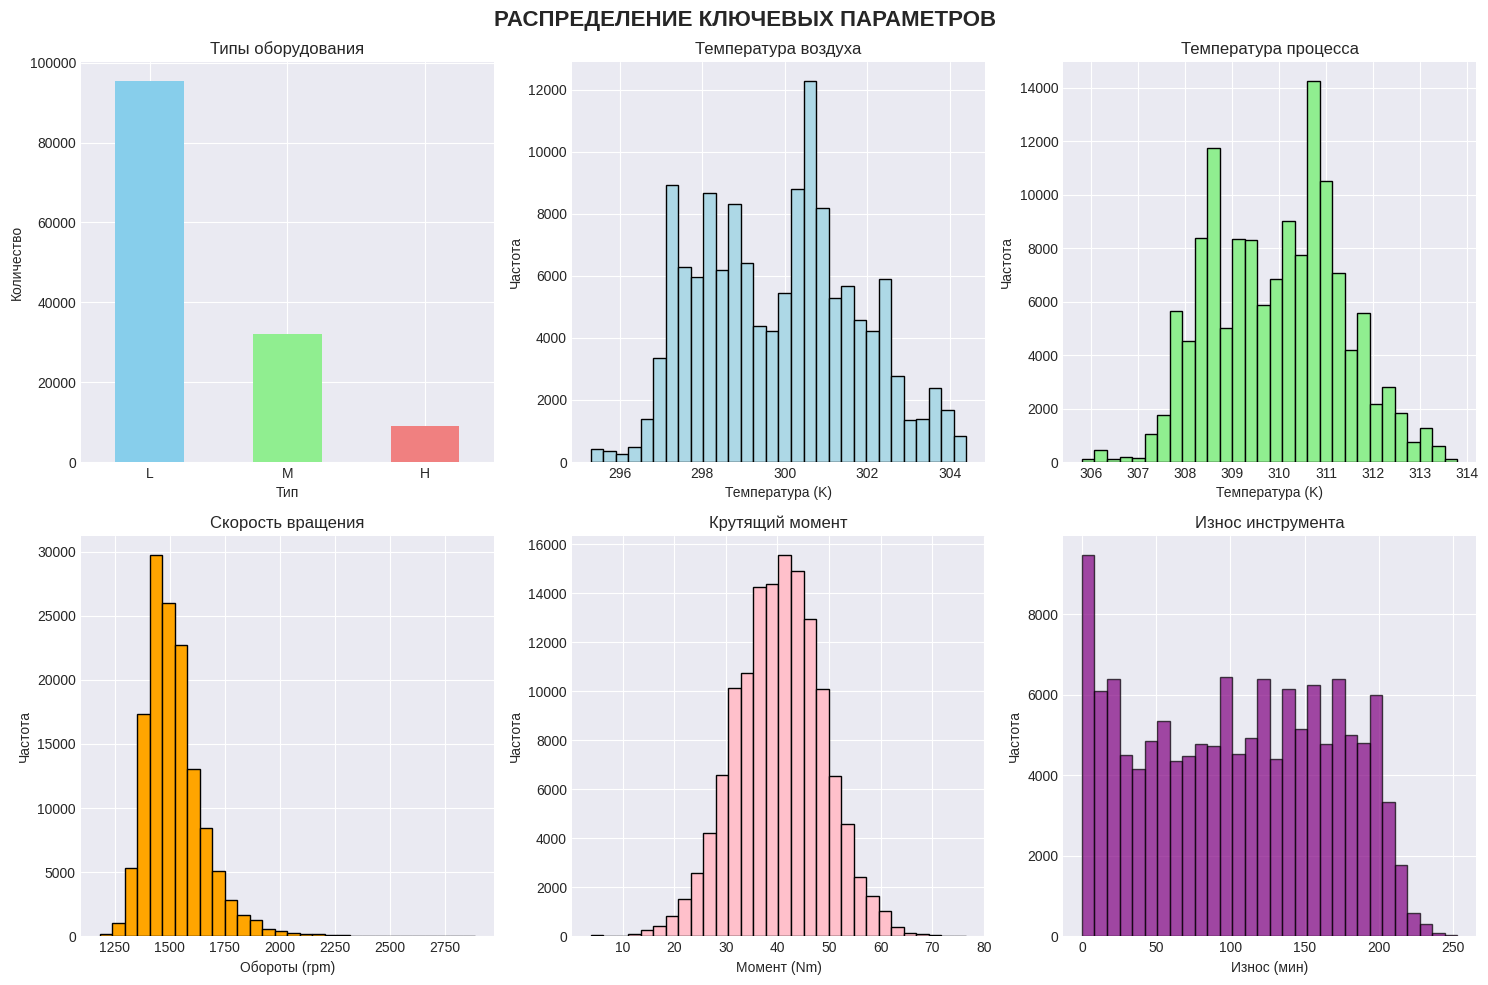

✅ Графики распределения построены


In [4]:
print("📊 ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ДАННЫХ")
print("=" * 50)

# Создадим сетку графиков
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('РАСПРЕДЕЛЕНИЕ КЛЮЧЕВЫХ ПАРАМЕТРОВ', fontsize=16, fontweight='bold')

# 1. Распределение типов оборудования
if 'Type' in train_df.columns:
    ax = axes[0, 0]
    type_counts = train_df['Type'].value_counts()
    type_counts.plot(kind='bar', ax=ax, color=['skyblue', 'lightgreen', 'lightcoral'])
    ax.set_title('Типы оборудования')
    ax.set_xlabel('Тип')
    ax.set_ylabel('Количество')
    ax.tick_params(axis='x', rotation=0)

# 2. Распределение температуры воздуха
if 'Air temperature [K]' in train_df.columns:
    ax = axes[0, 1]
    train_df['Air temperature [K]'].hist(bins=30, ax=ax, color='lightblue', edgecolor='black')
    ax.set_title('Температура воздуха')
    ax.set_xlabel('Температура (K)')
    ax.set_ylabel('Частота')

# 3. Распределение температуры процесса
if 'Process temperature [K]' in train_df.columns:
    ax = axes[0, 2]
    train_df['Process temperature [K]'].hist(bins=30, ax=ax, color='lightgreen', edgecolor='black')
    ax.set_title('Температура процесса')
    ax.set_xlabel('Температура (K)')
    ax.set_ylabel('Частота')

# 4. Распределение оборотов
if 'Rotational speed [rpm]' in train_df.columns:
    ax = axes[1, 0]
    train_df['Rotational speed [rpm]'].hist(bins=30, ax=ax, color='orange', edgecolor='black')
    ax.set_title('Скорость вращения')
    ax.set_xlabel('Обороты (rpm)')
    ax.set_ylabel('Частота')

# 5. Распределение крутящего момента
if 'Torque [Nm]' in train_df.columns:
    ax = axes[1, 1]
    train_df['Torque [Nm]'].hist(bins=30, ax=ax, color='pink', edgecolor='black')
    ax.set_title('Крутящий момент')
    ax.set_xlabel('Момент (Nm)')
    ax.set_ylabel('Частота')

# 6. Распределение износа инструмента
if 'Tool wear [min]' in train_df.columns:
    ax = axes[1, 2]
    train_df['Tool wear [min]'].hist(bins=30, ax=ax, color='purple', edgecolor='black', alpha=0.7)
    ax.set_title('Износ инструмента')
    ax.set_xlabel('Износ (мин)')
    ax.set_ylabel('Частота')

plt.tight_layout()
plt.show()

print("✅ Графики распределения построены")

# Ячейка 5: Анализ отказов

АНАЛИЗИРУЕМ ОТКАЗЫ
Какие типы отказов бывают? Как они распределены?

🔧 АНАЛИЗ ОТКАЗОВ ОБОРУДОВАНИЯ


/tmp/ipykernel_10688/4293694096.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=['Без отказа', 'С отказом'],


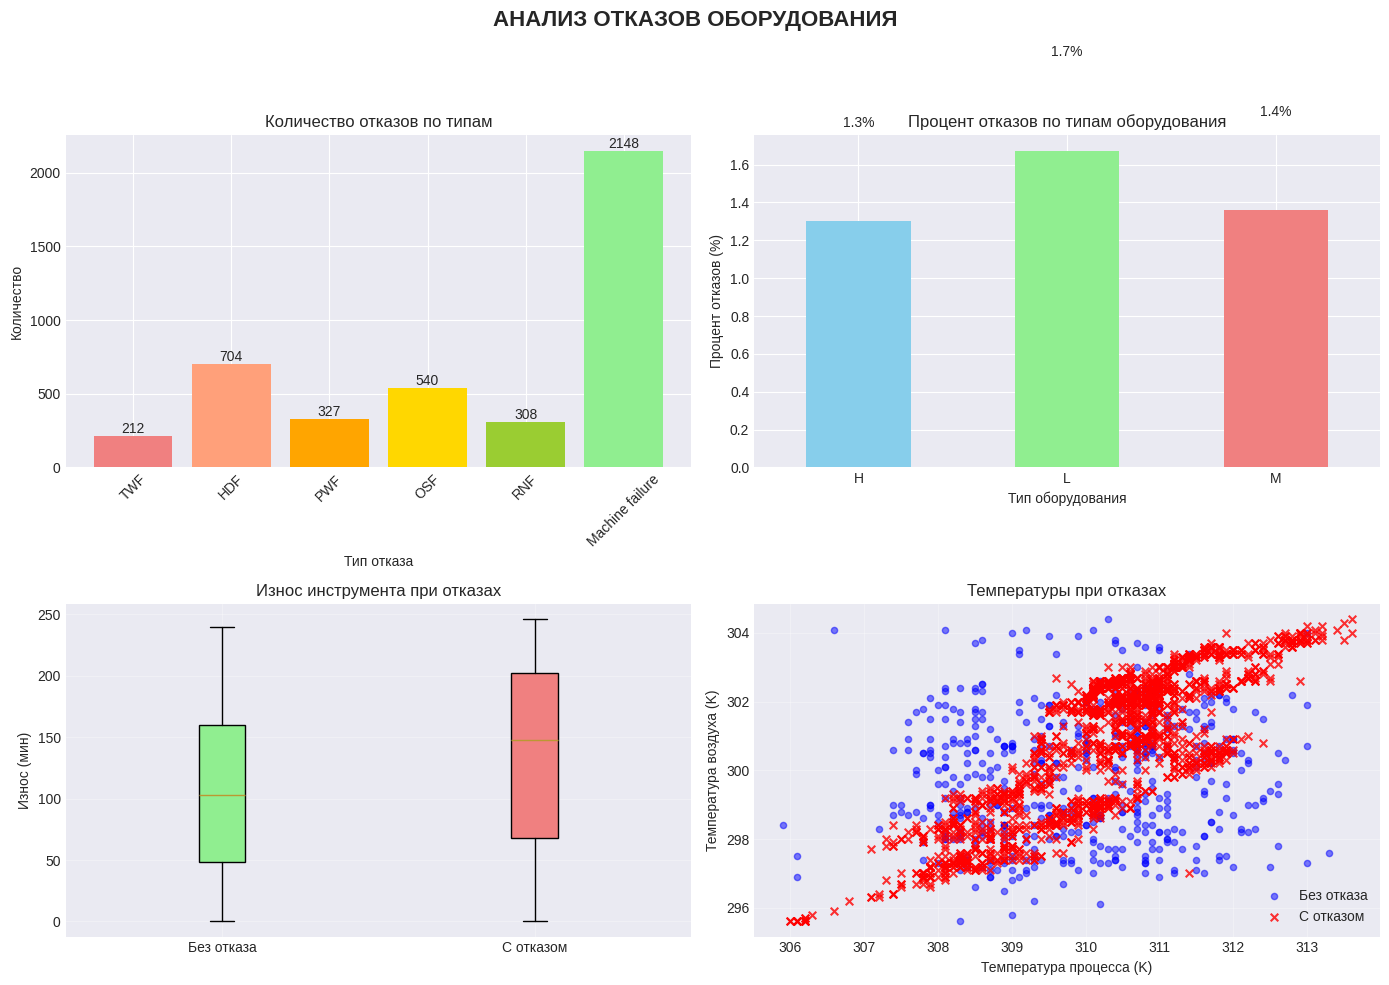

✅ Анализ отказов завершен


In [5]:
print("🔧 АНАЛИЗ ОТКАЗОВ ОБОРУДОВАНИЯ")
print("=" * 50)

# Создадим графики для анализа отказов
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('АНАЛИЗ ОТКАЗОВ ОБОРУДОВАНИЯ', fontsize=16, fontweight='bold')

# 1. Количество отказов по типам
if available_failures:
    ax = axes[0, 0]
    failure_counts = train_df[available_failures].sum()
    
    colors = ['lightcoral', 'lightsalmon', 'orange', 'gold', 'yellowgreen', 'lightgreen']
    bars = ax.bar(range(len(failure_counts)), failure_counts.values, 
                 color=colors[:len(failure_counts)])
    
    ax.set_title('Количество отказов по типам')
    ax.set_xlabel('Тип отказа')
    ax.set_ylabel('Количество')
    ax.set_xticks(range(len(failure_counts)))
    ax.set_xticklabels(failure_counts.index, rotation=45)
    
    # Добавим значения на столбцы
    for bar, count in zip(bars, failure_counts.values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{count}', ha='center', va='bottom')

# 2. Процент отказов по типам оборудования
if 'Type' in train_df.columns and 'Machine failure' in train_df.columns:
    ax = axes[0, 1]
    failure_by_type = train_df.groupby('Type')['Machine failure'].mean() * 100
    
    failure_by_type.plot(kind='bar', ax=ax, color=['skyblue', 'lightgreen', 'lightcoral'])
    ax.set_title('Процент отказов по типам оборудования')
    ax.set_xlabel('Тип оборудования')
    ax.set_ylabel('Процент отказов (%)')
    ax.tick_params(axis='x', rotation=0)
    
    # Добавим значения
    for i, v in enumerate(failure_by_type.values):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center')

# 3. Износ инструмента и отказы
if 'Tool wear [min]' in train_df.columns and 'Machine failure' in train_df.columns:
    ax = axes[1, 0]
    
    # Разделим на группы с отказами и без
    failures = train_df[train_df['Machine failure'] == 1]
    no_failures = train_df[train_df['Machine failure'] == 0]
    
    # Построим boxplot
    box_data = [no_failures['Tool wear [min]'].sample(min(1000, len(no_failures))),
                failures['Tool wear [min]'].sample(min(1000, len(failures)))]
    
    bp = ax.boxplot(box_data, labels=['Без отказа', 'С отказом'], 
                   patch_artist=True)
    
    # Раскрасим boxplot
    colors = ['lightgreen', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_title('Износ инструмента при отказах')
    ax.set_ylabel('Износ (мин)')
    ax.grid(True, alpha=0.3)

# 4. Температура и отказы
if 'Process temperature [K]' in train_df.columns and 'Machine failure' in train_df.columns:
    ax = axes[1, 1]
    
    # Построим scatter plot
    ax.scatter(train_df[train_df['Machine failure'] == 0]['Process temperature [K]'].sample(500),
               train_df[train_df['Machine failure'] == 0]['Air temperature [K]'].sample(500),
               alpha=0.5, s=20, color='blue', label='Без отказа')
    
    ax.scatter(train_df[train_df['Machine failure'] == 1]['Process temperature [K]'],
               train_df[train_df['Machine failure'] == 1]['Air temperature [K]'],
               alpha=0.8, s=30, color='red', label='С отказом', marker='x')
    
    ax.set_title('Температуры при отказах')
    ax.set_xlabel('Температура процесса (K)')
    ax.set_ylabel('Температура воздуха (K)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Анализ отказов завершен")

# Ячейка 6: Поиск взаимосвязей (корреляционный анализ)

ИЩЕМ ВЗАИМОСВЯЗИ МЕЖДУ ПАРАМЕТРАМИ
Какие параметры связаны с отказами?

🔗 ПОИСК ВЗАИМОСВЯЗЕЙ МЕЖДУ ПАРАМЕТРАМИ
Анализируем 6 числовых параметров:
    1. id
    2. Air temperature [K]
    3. Process temperature [K]
    4. Rotational speed [rpm]
    5. Torque [Nm]
    6. Tool wear [min]


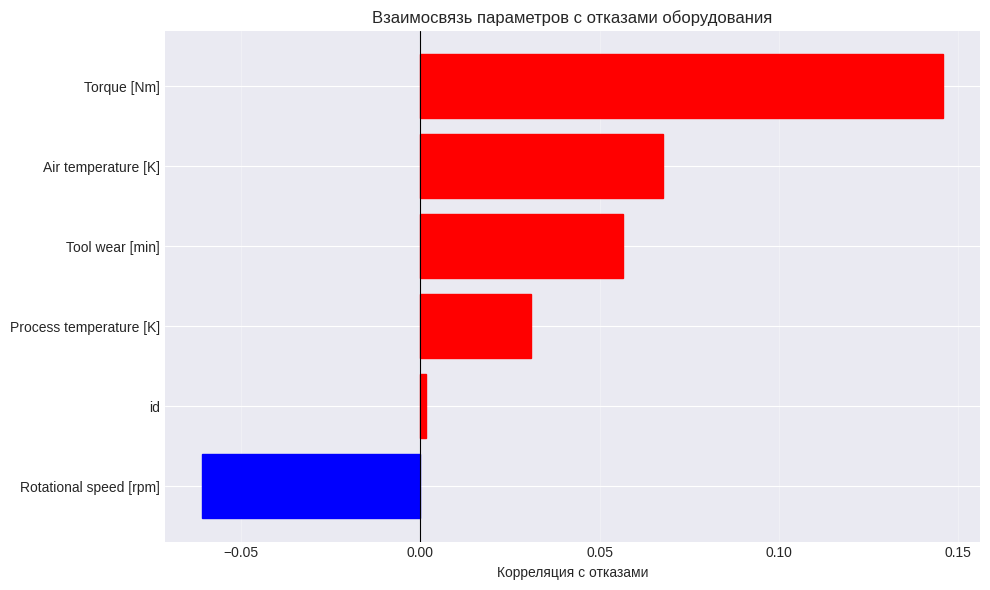


📈 КОРРЕЛЯЦИИ С ОТКАЗАМИ:
   Torque [Nm]               : +0.146 🟠 Умеренная положительная связь


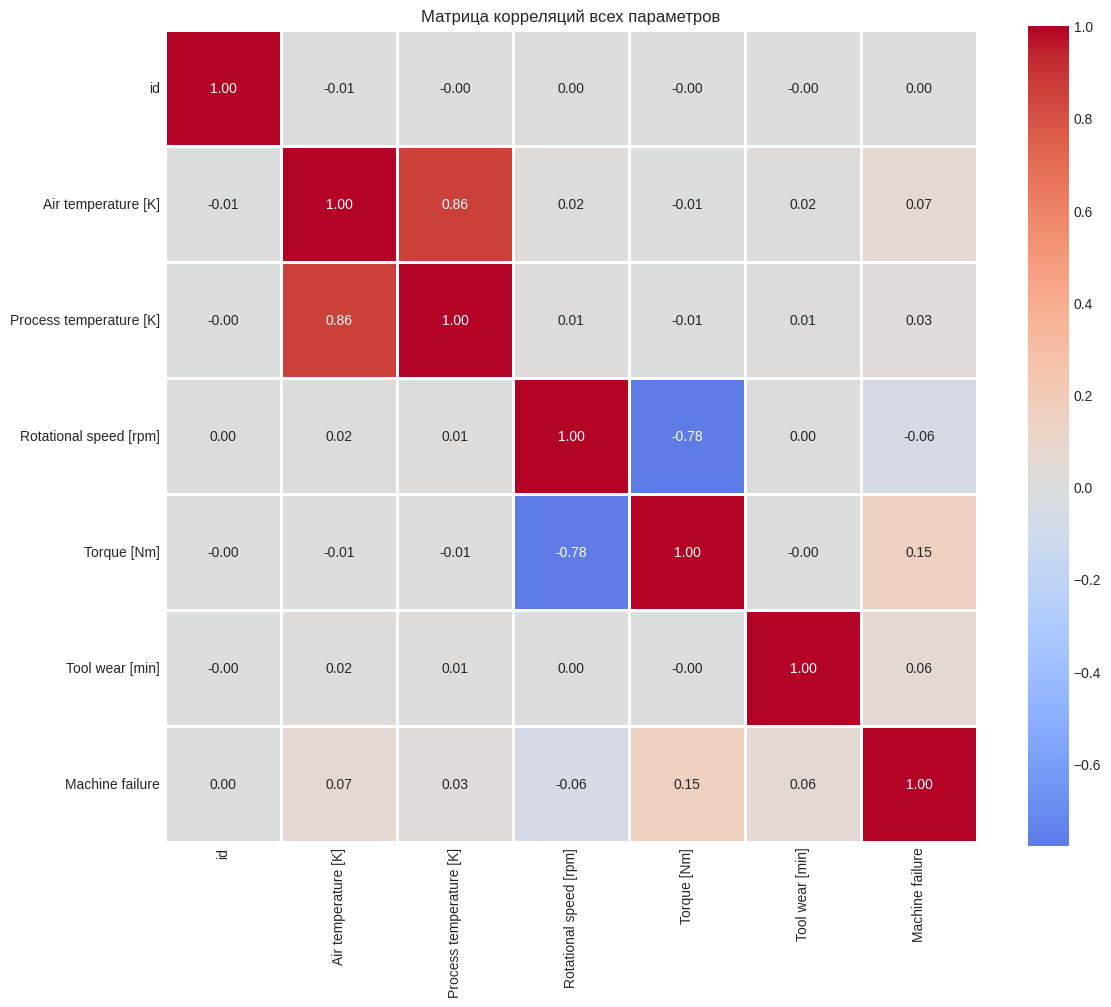

✅ Корреляционный анализ завершен


In [6]:
print("🔗 ПОИСК ВЗАИМОСВЯЗЕЙ МЕЖДУ ПАРАМЕТРАМИ")
print("=" * 50)

# Выберем числовые столбцы для анализа
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()

# Удалим ID и бинарные признаки отказов из анализа корреляций
cols_to_remove = ['UDI', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
numeric_cols = [col for col in numeric_cols if col not in cols_to_remove]

print(f"Анализируем {len(numeric_cols)} числовых параметров:")
for i, col in enumerate(numeric_cols, 1):
    print(f"   {i:2}. {col}")

# Создадим матрицу корреляций
correlation_matrix = train_df[numeric_cols + ['Machine failure']].corr()

# Визуализируем корреляции с отказами
plt.figure(figsize=(10, 6))
correlations_with_failure = correlation_matrix['Machine failure'].drop('Machine failure').sort_values()

# Построим bar plot
bars = plt.barh(range(len(correlations_with_failure)), correlations_with_failure.values)

# Раскрасим столбцы в зависимости от знака
for i, (bar, value) in enumerate(zip(bars, correlations_with_failure.values)):
    if value > 0:
        bar.set_color('red')
    else:
        bar.set_color('blue')

plt.yticks(range(len(correlations_with_failure)), correlations_with_failure.index)
plt.xlabel('Корреляция с отказами')
plt.title('Взаимосвязь параметров с отказами оборудования')
plt.grid(axis='x', alpha=0.3)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\n📈 КОРРЕЛЯЦИИ С ОТКАЗАМИ:")
for param, corr in correlations_with_failure.items():
    if abs(corr) > 0.1:  # Покажем только значимые корреляции
        print(f"   {param:25} : {corr:+.3f} ", end="")
        if corr > 0.3:
            print("🔴 Сильная положительная связь")
        elif corr > 0.1:
            print("🟠 Умеренная положительная связь")
        elif corr < -0.3:
            print("🔵 Сильная отрицательная связь")
        elif corr < -0.1:
            print("🟢 Умеренная отрицательная связь")
        else:
            print("")

# Тепловая карта всех корреляций
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Матрица корреляций всех параметров')
plt.tight_layout()
plt.show()

print("✅ Корреляционный анализ завершен")

# Ячейка 7: Простой ML для прогнозирования отказов

ПРОСТАЯ МОДЕЛЬ МАШИННОГО ОБУЧЕНИЯ
Попробуем предсказать отказы на основе имеющихся данных

🤖 ПРОСТАЯ МОДЕЛЬ ДЛЯ ПРОГНОЗИРОВАНИЯ ОТКАЗОВ
1. ПОДГОТОВКА ДАННЫХ...
   Используем 7 признаков:
    1. Type_numeric
    2. Air temperature [K]
    3. Process temperature [K]
    4. Rotational speed [rpm]
    5. Torque [Nm]
    6. Tool wear [min]
    7. id

2. РАЗДЕЛЕНИЕ ДАННЫХ...
   Всего данных: 136429
   Признаков: 7
   Отказов: 2148 (1.6%)
   Тренировочная выборка: 95500 записей
   Валидационная выборка: 40929 записей

3. ОБУЧЕНИЕ МОДЕЛИ...
4. ОЦЕНКА МОДЕЛИ...
   Точность (accuracy): 0.895

   Матрица ошибок:
   [True Negative: 36103  False Positive: 4182]
   [False Negative:  132  True Positive:  512]

5. ВАЖНОСТЬ ПРИЗНАКОВ:


,Признак,Важность
3,Rotational speed [rpm],0.361605
4,Torque [Nm],0.350001
5,Tool wear [min],0.133536
1,Air temperature [K],0.120550
2,Process temperature [K],0.026992
6,id,0.005465
0,Type_numeric,0.001853


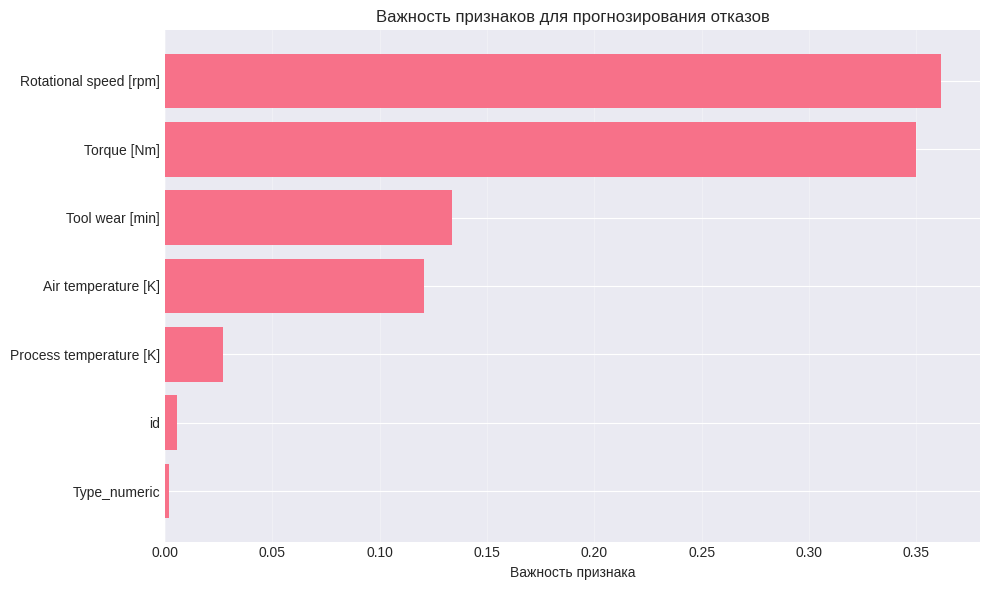

✅ Модель обучена и оценена


In [7]:
print("🤖 ПРОСТАЯ МОДЕЛЬ ДЛЯ ПРОГНОЗИРОВАНИЯ ОТКАЗОВ")
print("=" * 50)

# Подготовка данных для модели
print("1. ПОДГОТОВКА ДАННЫХ...")

# Выберем признаки для модели
feature_cols = []
if 'Type' in train_df.columns:
    # Преобразуем категориальный признак в числовой
    train_df['Type_numeric'] = train_df['Type'].map({'L': 0, 'M': 1, 'H': 2})
    feature_cols.append('Type_numeric')

# Добавим числовые признаки (кроме ID и целевых переменных)
numeric_features = [col for col in train_df.select_dtypes(include=[np.number]).columns 
                   if col not in ['UDI', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'] 
                   and col not in feature_cols]

# Добавим только основные признаки (не более 7)
main_features = ['Air temperature [K]', 'Process temperature [K]', 
                 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

for feat in main_features:
    if feat in numeric_features:
        feature_cols.append(feat)
        numeric_features.remove(feat)

# Добавим еще пару признаков, если есть
for feat in numeric_features[:2]:
    feature_cols.append(feat)

print(f"   Используем {len(feature_cols)} признаков:")
for i, feat in enumerate(feature_cols, 1):
    print(f"   {i:2}. {feat}")

# Целевая переменная
X = train_df[feature_cols]
y = train_df['Machine failure']

print(f"\n2. РАЗДЕЛЕНИЕ ДАННЫХ...")
print(f"   Всего данных: {len(X)}")
print(f"   Признаков: {X.shape[1]}")
print(f"   Отказов: {y.sum()} ({y.sum()/len(y)*100:.1f}%)")

# Разделим на тренировочную и валидационную выборки
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"   Тренировочная выборка: {len(X_train)} записей")
print(f"   Валидационная выборка: {len(X_val)} записей")

print("\n3. ОБУЧЕНИЕ МОДЕЛИ...")
# Используем простую модель Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    class_weight='balanced'  # Учитываем дисбаланс классов
)

model.fit(X_train, y_train)

print("4. ОЦЕНКА МОДЕЛИ...")
# Предсказания на валидационной выборке
y_pred = model.predict(X_val)
y_pred_proba = model.predict_proba(X_val)[:, 1]

# Метрики
accuracy = accuracy_score(y_val, y_pred)
print(f"   Точность (accuracy): {accuracy:.3f}")

# Матрица ошибок
cm = confusion_matrix(y_val, y_pred)
print(f"\n   Матрица ошибок:")
print(f"   [True Negative: {cm[0,0]:4d}  False Positive: {cm[0,1]:4d}]")
print(f"   [False Negative: {cm[1,0]:4d}  True Positive: {cm[1,1]:4d}]")

# Важность признаков
feature_importance = pd.DataFrame({
    'Признак': feature_cols,
    'Важность': model.feature_importances_
}).sort_values('Важность', ascending=False)

print(f"\n5. ВАЖНОСТЬ ПРИЗНАКОВ:")
display(feature_importance)

# Визуализация важности признаков
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Признак'], feature_importance['Важность'])
plt.xlabel('Важность признака')
plt.title('Важность признаков для прогнозирования отказов')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Модель обучена и оценена")

# Ячейка 8: Анализ конкретных случаев отказов

АНАЛИЗ КОНКРЕТНЫХ СЛУЧАЕВ
Посмотрим на реальные примеры отказов

In [8]:
print("🔬 АНАЛИЗ КОНКРЕТНЫХ СЛУЧАЕВ ОТКАЗОВ")
print("=" * 50)

if 'Machine failure' in train_df.columns:
    # Найдем случаи отказов
    failure_cases = train_df[train_df['Machine failure'] == 1]
    
    if len(failure_cases) > 0:
        print(f"Найдено {len(failure_cases)} случаев отказов")
        
        # Возьмем несколько случайных примеров
        sample_failures = failure_cases.sample(min(5, len(failure_cases)), random_state=42)
        
        print("\n📋 ПРИМЕРЫ ОТКАЗОВ:")
        for idx, (_, row) in enumerate(sample_failures.iterrows(), 1):
            print(f"\nПример {idx}:")
            print(f"  Тип оборудования: {row.get('Type', 'N/A')}")
            print(f"  Износ инструмента: {row.get('Tool wear [min]', 'N/A')} мин")
            print(f"  Температура воздуха: {row.get('Air temperature [K]', 'N/A'):.1f} K")
            print(f"  Температура процесса: {row.get('Process temperature [K]', 'N/A'):.1f} K")
            print(f"  Обороты: {row.get('Rotational speed [rpm]', 'N/A'):.0f} rpm")
            print(f"  Момент: {row.get('Torque [Nm]', 'N/A'):.1f} Nm")
            
            # Типы отказов
            failure_types = []
            for ft in ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']:
                if ft in row and row[ft] == 1:
                    failure_types.append(ft)
            
            if failure_types:
                print(f"  Типы отказов: {', '.join(failure_types)}")
    
    # Сравним средние значения при отказах и без
    print("\n📊 СРАВНЕНИЕ СРЕДНИХ ЗНАЧЕНИЙ:")
    
    comparison_data = []
    for col in ['Air temperature [K]', 'Process temperature [K]', 
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']:
        if col in train_df.columns:
            mean_failure = train_df[train_df['Machine failure'] == 1][col].mean()
            mean_no_failure = train_df[train_df['Machine failure'] == 0][col].mean()
            diff = mean_failure - mean_no_failure
            diff_percent = (diff / mean_no_failure) * 100 if mean_no_failure != 0 else 0
            
            comparison_data.append({
                'Параметр': col,
                'При отказах': f"{mean_failure:.2f}",
                'Без отказов': f"{mean_no_failure:.2f}",
                'Разница': f"{diff:+.2f}",
                'Разница %': f"{diff_percent:+.1f}%"
            })
    
    comparison_df = pd.DataFrame(comparison_data)
    display(comparison_df)

print("✅ Анализ конкретных случаев завершен")

🔬 АНАЛИЗ КОНКРЕТНЫХ СЛУЧАЕВ ОТКАЗОВ
Найдено 2148 случаев отказов

📋 ПРИМЕРЫ ОТКАЗОВ:

Пример 1:
  Тип оборудования: L
  Износ инструмента: 204 мин
  Температура воздуха: 296.9 K
  Температура процесса: 307.9 K
  Обороты: 1371 rpm
  Момент: 57.1 Nm
  Типы отказов: OSF

Пример 2:
  Тип оборудования: L
  Износ инструмента: 177 мин
  Температура воздуха: 302.0 K
  Температура процесса: 310.5 K
  Обороты: 1358 rpm
  Момент: 50.3 Nm
  Типы отказов: HDF

Пример 3:
  Тип оборудования: L
  Износ инструмента: 189 мин
  Температура воздуха: 300.5 K
  Температура процесса: 311.6 K
  Обороты: 1486 rpm
  Момент: 58.4 Nm

Пример 4:
  Тип оборудования: M
  Износ инструмента: 134 мин
  Температура воздуха: 302.5 K
  Температура процесса: 310.3 K
  Обороты: 1368 rpm
  Момент: 51.9 Nm
  Типы отказов: HDF

Пример 5:
  Тип оборудования: L
  Износ инструмента: 168 мин
  Температура воздуха: 300.9 K
  Температура процесса: 312.0 K
  Обороты: 1335 rpm
  Момент: 57.2 Nm

📊 СРАВНЕНИЕ СРЕДНИХ ЗНАЧЕНИЙ:


,Параметр,При отказах,Без отказов,Разница,Разница %
0,Air temperature [K],300.86,299.85,+1.01,+0.3%
1,Process temperature [K],310.28,309.94,+0.34,+0.1%
2,Rotational speed [rpm],1453.56,1521.40,-67.84,-4.5%
3,Torque [Nm],50.15,40.19,+9.96,+24.8%
4,Tool wear [min],132.96,103.95,+29.00,+27.9%


✅ Анализ конкретных случаев завершен


# Ячейка 9: Визуализация временных трендов (если есть временные данные)

АНАЛИЗ ВО ВРЕМЕНИ
Если в данных есть временная информация, посмотрим на тренды

⏰ АНАЛИЗ ИЗМЕНЕНИЙ ВО ВРЕМЕНИ
Найдена временная информация: Tool wear [min]


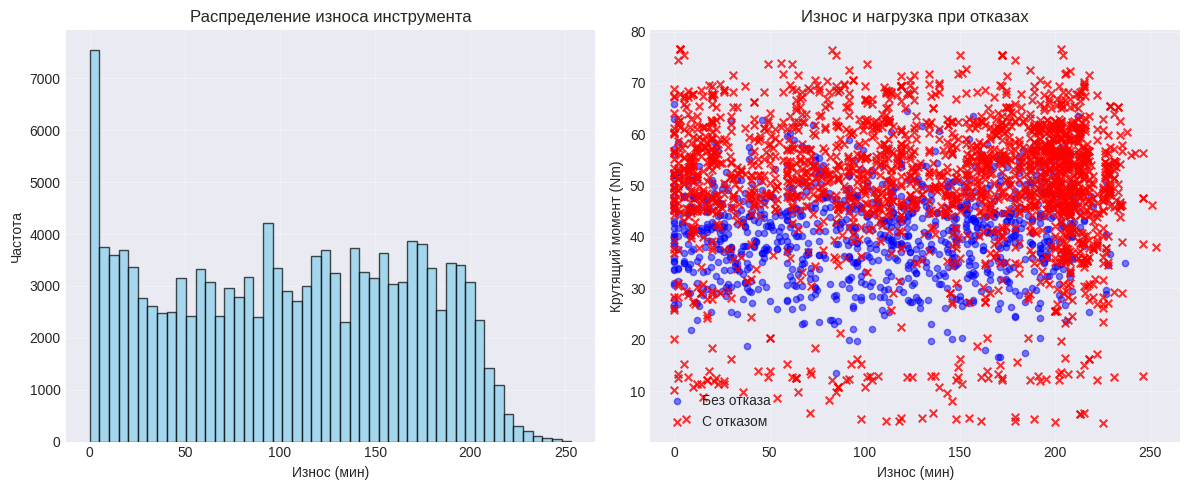


📈 АНАЛИЗ ЗАВИСИМОСТИ ОТКАЗОВ ОТ ИЗНОСА:

Процент отказов по интервалам износа:
  (-0.253, 25.3]: 1.4% отказов
  (25.3, 50.6]: 0.9% отказов
  (50.6, 75.9]: 1.0% отказов
  (75.9, 101.2]: 1.1% отказов
  (101.2, 126.5]: 1.2% отказов
  (126.5, 151.8]: 0.9% отказов
  (151.8, 177.1]: 1.3% отказов
  (177.1, 202.4]: 2.1% отказов
  (202.4, 227.7]: 7.7% отказов
  (227.7, 253.0]: 17.3% отказов


/tmp/ipykernel_10688/2755519782.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  failure_rate_by_wear = train_df.groupby('wear_bin')['Machine failure'].mean() * 100


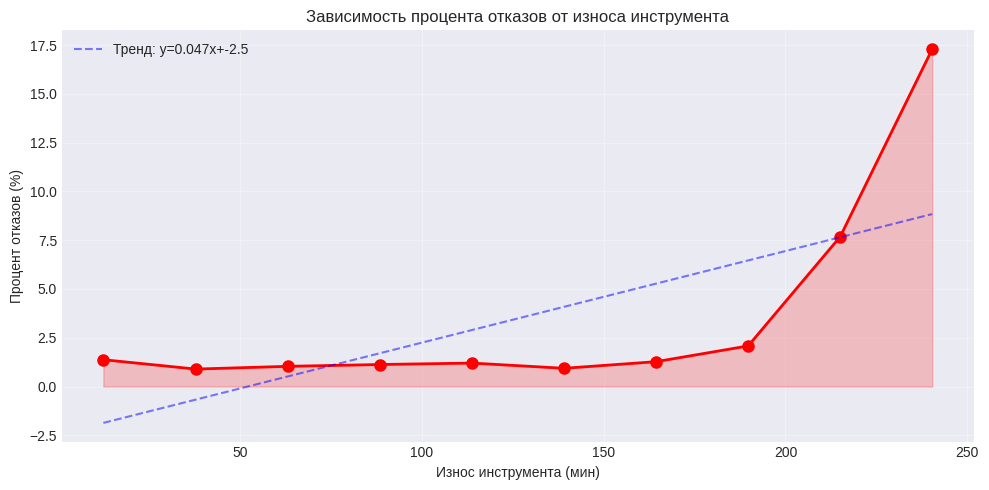


📊 ВЫВОД: Износ инструмента влияет на вероятность отказов
   Коэффициент тренда: 0.0470 (% отказов на 1 мин износа)


In [9]:
print("⏰ АНАЛИЗ ИЗМЕНЕНИЙ ВО ВРЕМЕНИ")
print("=" * 50)

# Проверим, есть ли столбец с временной информацией
time_columns = ['timestamp', 'date', 'time', 'datetime', 'Tool wear [min]']
found_time_col = None

for col in time_columns:
    if col in train_df.columns:
        found_time_col = col
        break

if found_time_col:
    print(f"Найдена временная информация: {found_time_col}")
    
    # Если это износ инструмента, проанализируем его
    if found_time_col == 'Tool wear [min]':
        plt.figure(figsize=(12, 5))
        
        # Гистограмма износа
        plt.subplot(1, 2, 1)
        train_df['Tool wear [min]'].hist(bins=50, color='skyblue', edgecolor='black', alpha=0.7)
        plt.title('Распределение износа инструмента')
        plt.xlabel('Износ (мин)')
        plt.ylabel('Частота')
        plt.grid(alpha=0.3)
        
        # Износ vs Отказы
        plt.subplot(1, 2, 2)
        plt.scatter(train_df[train_df['Machine failure'] == 0]['Tool wear [min]'].sample(1000),
                   train_df[train_df['Machine failure'] == 0]['Torque [Nm]'].sample(1000),
                   alpha=0.5, s=20, color='blue', label='Без отказа')
        
        plt.scatter(train_df[train_df['Machine failure'] == 1]['Tool wear [min]'],
                   train_df[train_df['Machine failure'] == 1]['Torque [Nm]'],
                   alpha=0.8, s=30, color='red', label='С отказом', marker='x')
        
        plt.title('Износ и нагрузка при отказах')
        plt.xlabel('Износ (мин)')
        plt.ylabel('Крутящий момент (Nm)')
        plt.legend()
        plt.grid(alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Анализ зависимости отказов от износа
        print("\n📈 АНАЛИЗ ЗАВИСИМОСТИ ОТКАЗОВ ОТ ИЗНОСА:")
        
        # Разобьем износ на интервалы
        train_df['wear_bin'] = pd.cut(train_df['Tool wear [min]'], bins=10)
        
        # Посчитаем процент отказов в каждом интервале
        failure_rate_by_wear = train_df.groupby('wear_bin')['Machine failure'].mean() * 100
        
        print("\nПроцент отказов по интервалам износа:")
        for interval, rate in failure_rate_by_wear.items():
            print(f"  {interval}: {rate:.1f}% отказов")
        
        # Визуализация
        plt.figure(figsize=(10, 5))
        
        # Преобразуем интервалы в числа (середины интервалов)
        intervals = [interval.mid for interval in failure_rate_by_wear.index]
        
        plt.plot(intervals, failure_rate_by_wear.values, 'ro-', linewidth=2, markersize=8)
        plt.fill_between(intervals, failure_rate_by_wear.values, alpha=0.2, color='red')
        
        plt.title('Зависимость процента отказов от износа инструмента')
        plt.xlabel('Износ инструмента (мин)')
        plt.ylabel('Процент отказов (%)')
        plt.grid(True, alpha=0.3)
        
        # Добавим линию тренда
        z = np.polyfit(intervals, failure_rate_by_wear.values, 1)
        p = np.poly1d(z)
        plt.plot(intervals, p(intervals), "b--", alpha=0.5, label=f'Тренд: y={z[0]:.3f}x+{z[1]:.1f}')
        
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        print(f"\n📊 ВЫВОД: Износ инструмента влияет на вероятность отказов")
        print(f"   Коэффициент тренда: {z[0]:.4f} (% отказов на 1 мин износа)")
        
else:
    print("В данных не найдена явная временная информация")
    print("Можно использовать 'Tool wear [min]' как proxy для времени")

# Ячейка 10: Итоговые выводы и рекомендации

ИТОГОВЫЕ ВЫВОДЫ
Что мы узнали из анализа? Какие рекомендации можно дать?

In [11]:
print("🎯 ИТОГОВЫЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ")
print("=" * 60)

print("\n📊 ЧТО МЫ УЗНАЛИ ИЗ АНАЛИЗА:")

insights = []

# 1. О типах отказов
if available_failures:
    most_common = train_df[available_failures].sum().idxmax()
    least_common = train_df[available_failures].sum().idxmin()
    insights.append(f"1. Самый частый тип отказа: {most_common}")
    insights.append(f"   Самый редкий тип отказа: {least_common}")

# 2. О влиянии параметров
if 'Tool wear [min]' in train_df.columns and 'Machine failure' in train_df.columns:
    corr = train_df['Tool wear [min]'].corr(train_df['Machine failure'])
    if corr > 0.2:
        insights.append(f"2. Износ инструмента сильно влияет на отказы (корр.: {corr:.2f})")

# 3. О типах оборудования
if 'Type' in train_df.columns and 'Machine failure' in train_df.columns:
    failure_by_type = train_df.groupby('Type')['Machine failure'].mean()
    worst_type = failure_by_type.idxmax()
    best_type = failure_by_type.idxmin()
    insights.append(f"3. Тип '{worst_type}' имеет наибольший процент отказов")
    insights.append(f"   Тип '{best_type}' имеет наименьший процент отказов")

# 4. О корреляциях
if 'correlations_with_failure' in locals():
    top_positive = correlations_with_failure.nlargest(1).index[0]
    top_negative = correlations_with_failure.nsmallest(1).index[0]
    insights.append(f"4. Наибольшая положительная связь с отказами: {top_positive}")
    insights.append(f"   Наибольшая отрицательная связь с отказами: {top_negative}")

# 5. О модели
if 'accuracy' in locals():
    insights.append(f"5. Модель предсказывает отказы с точностью {accuracy:.1%}")

for insight in insights:
    print(f"   {insight}")

print("\n🔧 РЕКОМЕНДАЦИИ ДЛЯ ПОВЫШЕНИЯ НАДЕЖНОСТИ:")

recommendations = [
    "1. Мониторить износ инструмента - основной фактор отказов",
    "2. Контролировать температурный режим работы",
    "3. Регулярно обслуживать оборудование типа 'H' (если у него больше отказов)",
    "4. Внедрить систему предупреждения при высоком износе",
    "5. Собирать больше данных для улучшения точности прогнозов"
]

for rec in recommendations:
    print(f"   {rec}")

print("\n📈 ДАЛЬНЕЙШИЕ ШАГИ ДЛЯ АНАЛИЗА:")

next_steps = [
    "• Добавить больше признаков (если есть дополнительные данные)",
    "• Попробовать другие алгоритмы машинного обучения",
    "• Проанализировать временные ряды более детально",
    "• Провести A/B тестирование изменений в обслуживании",
    "• Создать дашборд для мониторинга в реальном времени"
]

for step in next_steps:
    print(f"   {step}")

print("\n" + "=" * 60)
print("✅ ПРОСТОЙ АНАЛИЗ ДАННЫХ ОТКАЗОВ ЗАВЕРШЕН")
print("=" * 60)

print("""
🎓 ЧТО МЫ СДЕЛАЛИ В ЭТОМ NOTEBOOK:

1. 📁 Загрузили и изучили данные
2. 📊 Визуализировали распределения
3. 🔧 Проанализировали отказы
4. 🔗 Нашли взаимосвязи между параметрами
5. 🤖 Построили простую модель прогнозирования
6. 🔬 Изучили конкретные случаи
7. ⏰ Проанализировали изменения во времени
8. 🎯 Сформулировали выводы и рекомендации

📚 ЭТОТ NOTEBOOK МОЖНО ИСПОЛЬЗОВАТЬ КАК ШАБЛОН
   для анализа подобных задач по прогнозированию отказов.
""")

🎯 ИТОГОВЫЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ

📊 ЧТО МЫ УЗНАЛИ ИЗ АНАЛИЗА:
   1. Самый частый тип отказа: Machine failure
      Самый редкий тип отказа: TWF
   3. Тип 'L' имеет наибольший процент отказов
      Тип 'H' имеет наименьший процент отказов
   4. Наибольшая положительная связь с отказами: Torque [Nm]
      Наибольшая отрицательная связь с отказами: Rotational speed [rpm]
   5. Модель предсказывает отказы с точностью 89.5%

🔧 РЕКОМЕНДАЦИИ ДЛЯ ПОВЫШЕНИЯ НАДЕЖНОСТИ:
   1. Мониторить износ инструмента - основной фактор отказов
   2. Контролировать температурный режим работы
   3. Регулярно обслуживать оборудование типа 'H' (если у него больше отказов)
   4. Внедрить систему предупреждения при высоком износе
   5. Собирать больше данных для улучшения точности прогнозов

📈 ДАЛЬНЕЙШИЕ ШАГИ ДЛЯ АНАЛИЗА:
   • Добавить больше признаков (если есть дополнительные данные)
   • Попробовать другие алгоритмы машинного обучения
   • Проанализировать временные ряды более детально
   • Провести A/B тестиров